# Classifier Run Comparison
This notebook visualizes the performance of the Baseline, Synthetic, and Synthetic Filtered classifier runs.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
df = pd.read_csv("runs_comparison.csv", index_col=0)
df

,val/auroc,val/auroc_Brocho-pneumonia,val/auroc_Bronchiolitis,val/auroc_Bronchitis,val/auroc_No finding,val/auroc_Other disease,val/auroc_Pneumonia,val/loss,train/loss,best_epoch
Run,,,,,,,,,,
Baseline,0.726353,0.740393,0.696086,0.732056,0.729692,0.687250,0.798680,1.019600,0.933030,48
Synthetic Filtered,0.721447,0.735396,0.683983,0.736212,0.726004,0.693021,0.796374,0.965660,0.923862,26
Synthetic,0.697313,0.712474,0.614620,0.670675,0.697125,0.685276,0.806155,0.914514,0.885171,47


## Training and Validation Curves
Visualizing the progress of loss and AUROC over epochs for all runs.

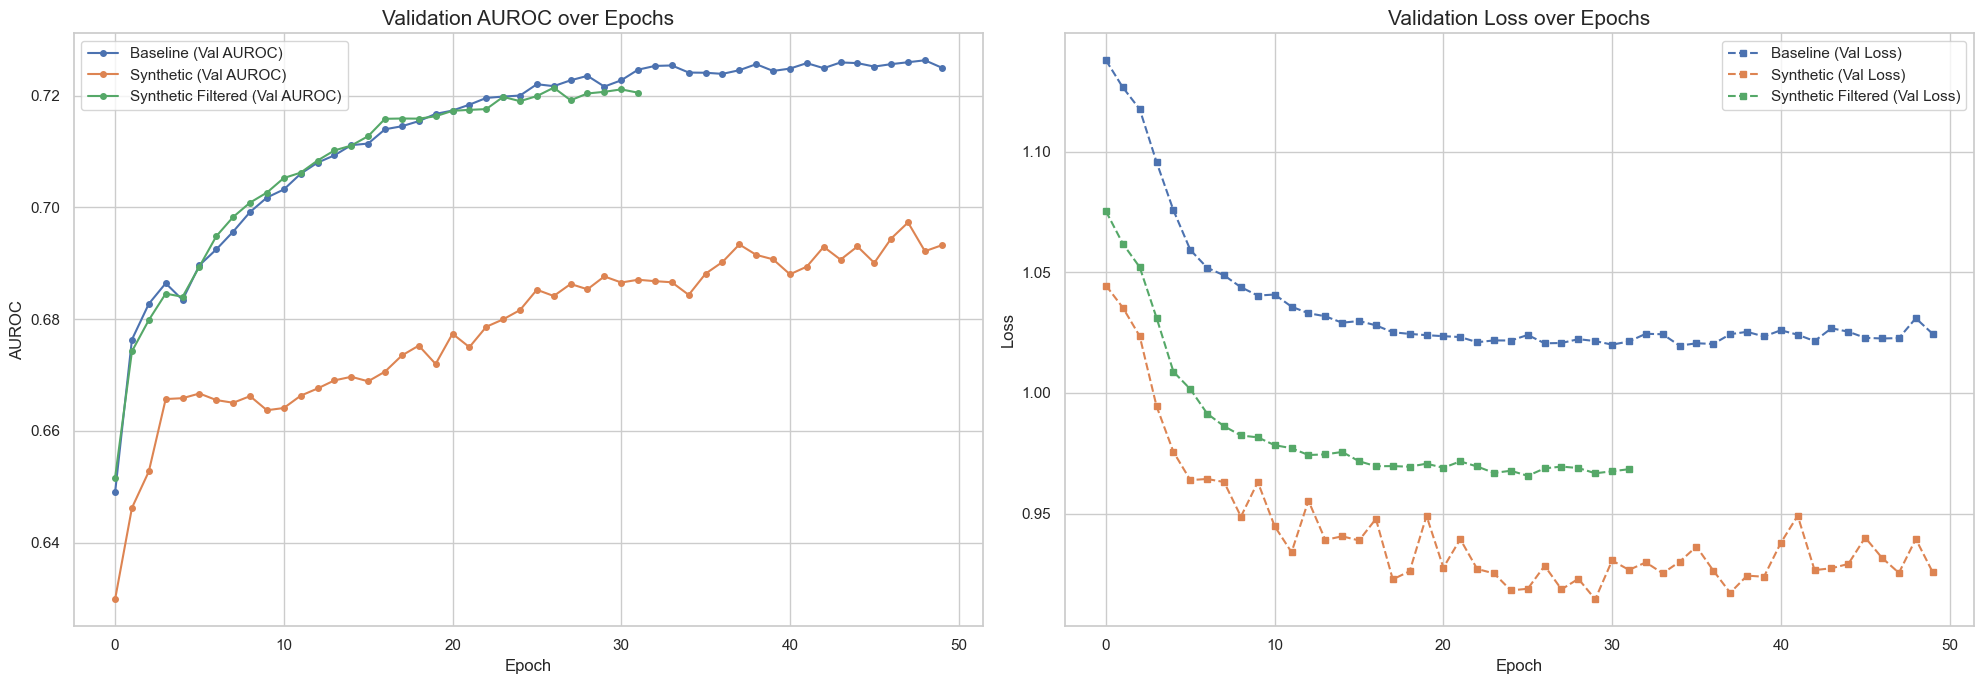

In [3]:
def load_metrics(run_name, run_dir):
    csv_path = os.path.join("..", "classifier", "runs", run_dir, "metrics.csv")
    if not os.path.exists(csv_path):
        import glob
        version_paths = glob.glob(os.path.join("..", "classifier", "runs", run_dir, "version_*", "metrics.csv"))
        if version_paths: csv_path = version_paths[0]
        else: return None
    
    df_run = pd.read_csv(csv_path)
    # Aggregate separate train/val rows
    df_run = df_run.groupby(['epoch']).first().reset_index()
    df_run['Run'] = run_name
    return df_run

run_configs = [
    ("Baseline", "baseline_slurm"),
    ("Synthetic", "synthetic_slurm"),
    ("Synthetic Filtered", "synthetic_filtered_slurm")
]

all_metrics = [load_metrics(name, d) for name, d in run_configs]
all_metrics = [m for m in all_metrics if m is not None]

if all_metrics:
    fig, axes = plt.subplots(1, 2, figsize=(20, 7))
    
    # Plot Validation AUROC
    for m in all_metrics:
        axes[0].plot(m['epoch'], m['val/auroc'], label=f"{m['Run'].iloc[0]} (Val AUROC)", marker='o', markersize=4)
    axes[0].set_title('Validation AUROC over Epochs', fontsize=15)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('AUROC')
    axes[0].legend()
    
    # Plot Validation Loss
    for m in all_metrics:
        axes[1].plot(m['epoch'], m['val/loss'], label=f"{m['Run'].iloc[0]} (Val Loss)", linestyle='--', marker='s', markersize=4)
    axes[1].set_title('Validation Loss over Epochs', fontsize=15)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

## Overall Performance (Best AUROC)
Comparing the maximum AUROC achieved during training for each run.

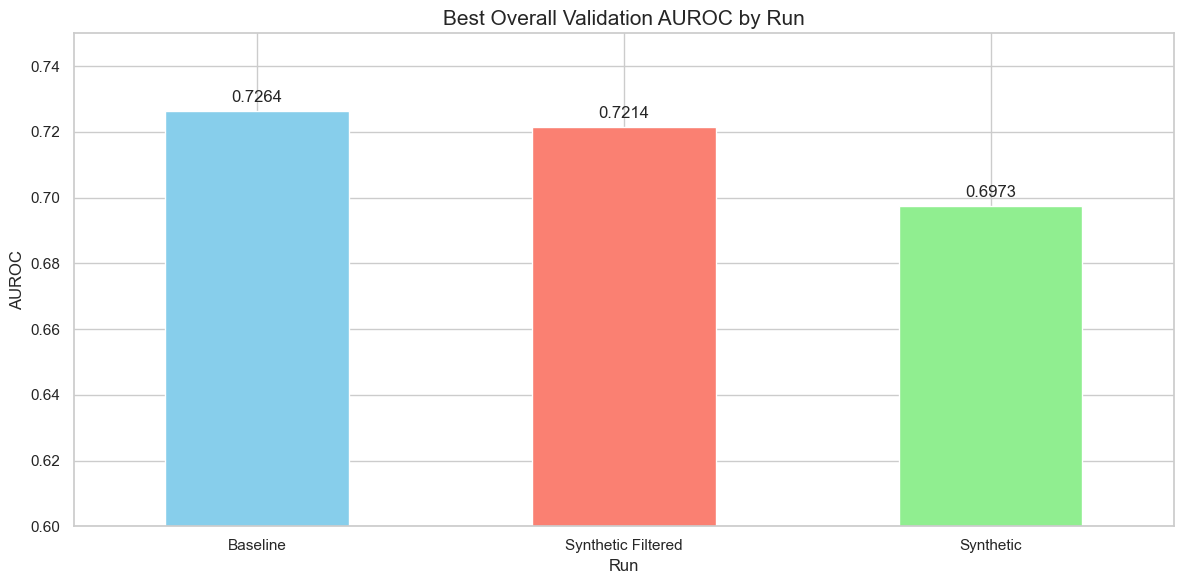

In [4]:
ax = df['val/auroc'].plot(kind='bar', color=['skyblue', 'salmon', 'lightgreen'])
plt.title('Best Overall Validation AUROC by Run', fontsize=15)
plt.ylabel('AUROC', fontsize=12)
plt.ylim(0.6, 0.75)
plt.xticks(rotation=0)

# Add value labels
for p in ax.patches:
    ax.annotate(f"{p.get_height():.4f}", (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.tight_layout()
plt.show()

## Per-Category AUROC Comparison
Breaking down performance by disease category.

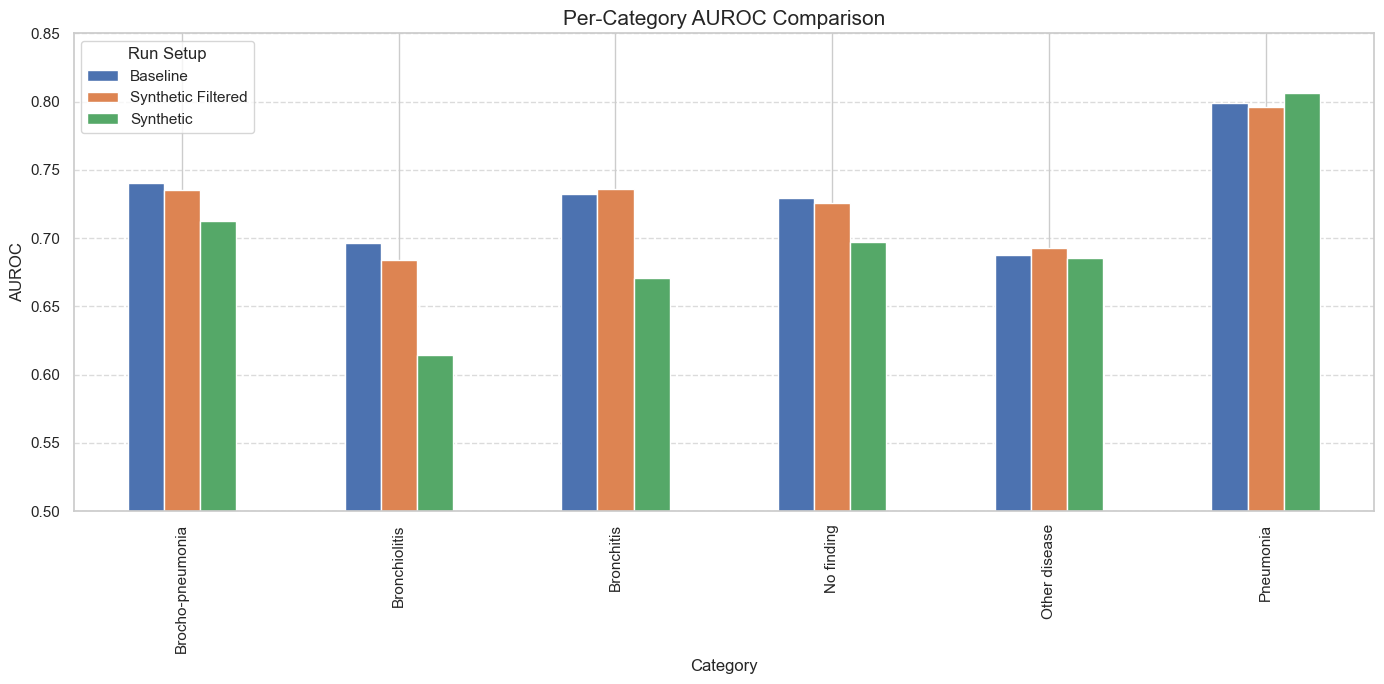

In [5]:
auroc_cols = [c for c in df.columns if 'val/auroc_' in c]
df_categories = df[auroc_cols].copy()
# Clean up column names
df_categories.columns = [c.replace('val/auroc_', '') for c in df_categories.columns]

df_categories.T.plot(kind='bar', figsize=(14, 7))
plt.title('Per-Category AUROC Comparison', fontsize=15)
plt.ylabel('AUROC', fontsize=12)
plt.xlabel('Category', fontsize=12)
plt.legend(title='Run Setup')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0.5, 0.85)
plt.tight_layout()
plt.show()

## Best Training/Validation Loss

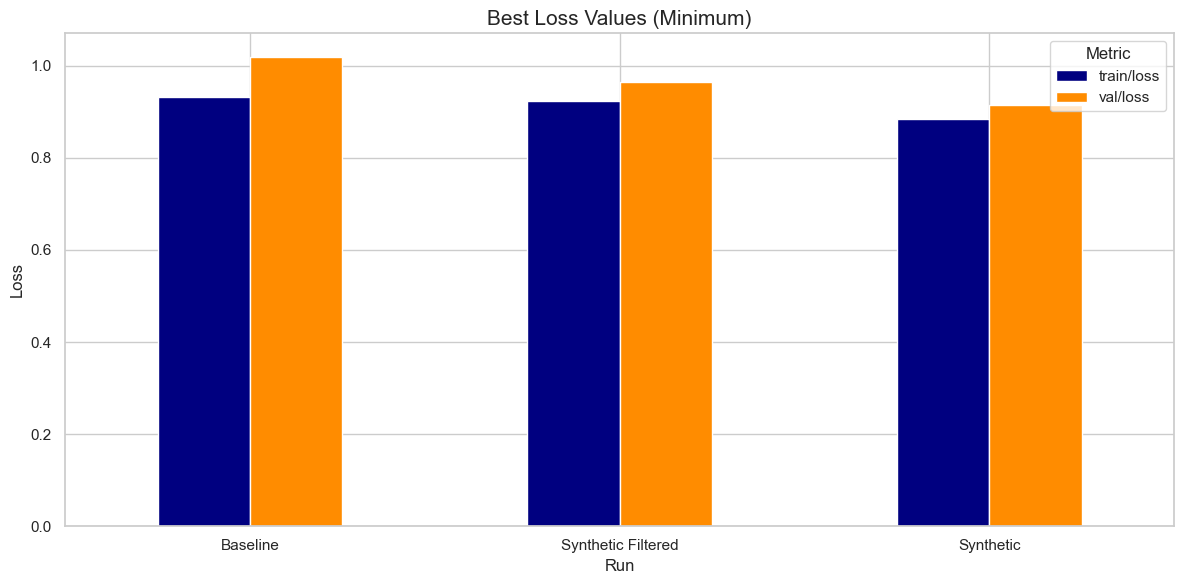

In [6]:
loss_cols = ['train/loss', 'val/loss']
df[loss_cols].plot(kind='bar', color=['navy', 'darkorange'])
plt.title('Best Loss Values (Minimum)', fontsize=15)
plt.ylabel('Loss', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()